In [1]:
import numpy as np

def generate_normal_2d(M, B, N):
    M = np.asarray(M)
    B = np.asarray(B)

    b00, b01 = B[0, 0], B[0, 1]
    b11 = B[1, 1]

    a00 = np.sqrt(b00)
    a10 = b01 / np.sqrt(b00)
    a11 = np.sqrt(b11 - (b01**2) / b00)

    X = np.zeros((N, 2))

    for i in range(N):
        xi1 = np.sum(np.random.rand(12)) - 6
        xi2 = np.sum(np.random.rand(12)) - 6

        x1 = M[0] + a00 * xi1
        x2 = M[1] + a10 * xi1 + a11 * xi2

        X[i, 0] = x1
        X[i, 1] = x2

    return X

def mahalanobis_distance(m1, m2, B):
    """
    m1, m2: средние векторы
    B: ковариационная матрица
    """
    m1 = np.asarray(m1)
    m2 = np.asarray(m2)
    B = np.asarray(B)
    
    diff = m1 - m2
    inv_B = np.linalg.inv(B)
    
    return diff.T @ inv_B @ diff


def bhattacharyya_distance(m1, m2, B1, B2):
    """
    m1, m2: средние векторы
    B1, B2: ковариационные матрицы распределений
    """
    m1 = np.asarray(m1)
    m2 = np.asarray(m2)
    B1 = np.asarray(B1)
    B2 = np.asarray(B2)
    
    B = 0.5 * (B1 + B2)
    
    diff = m1 - m2
    inv_B = np.linalg.inv(B)
    
    term1 = 0.25 * (diff.T @ inv_B @ diff)
    
    det_B = np.linalg.det(B)
    det_B1 = np.linalg.det(B1)
    det_B2 = np.linalg.det(B2)
    
    term2 = 0.5 * np.log(det_B / np.sqrt(det_B1 * det_B2))
    
    return term1 + term2

def plot_distribution_features(M, B, ax, color='black'):
    """
    Отрисовывает центр распределения и стрелки (главные компоненты),
    показывающие направления разброса данных.
    M - вектор математического ожидания (центр)
    B - ковариационная матрица
    ax - оси графика matplotlib
    """
    ax.scatter(M[0], M[1], color=color, marker='X', s=150, zorder=5, edgecolors='white')
    
    eigenvalues, eigenvectors = np.linalg.eigh(B)
    
    scale = 2.0 
    
    for i in range(2):
        direction = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * scale
        
        ax.annotate('', xy=M + direction, xytext=M,
                    arrowprops=dict(arrowstyle="->", color=color, lw=2.5, zorder=4))
        ax.annotate('', xy=M - direction, xytext=M,
                    arrowprops=dict(arrowstyle="->", color=color, lw=2.5, zorder=4))

7.142857142857143
Выборка 1:
Оценка среднего: [-0.99911966  1.0840213 ]
Оценка ковариации:
 [[0.71208905 0.07423735]
 [0.07423735 0.80481636]]

Выборка 2:
Оценка среднего: [-0.08159317 -0.92069853]
Оценка ковариации:
 [[ 0.66498652 -0.0220101 ]
 [-0.0220101   0.73293719]]


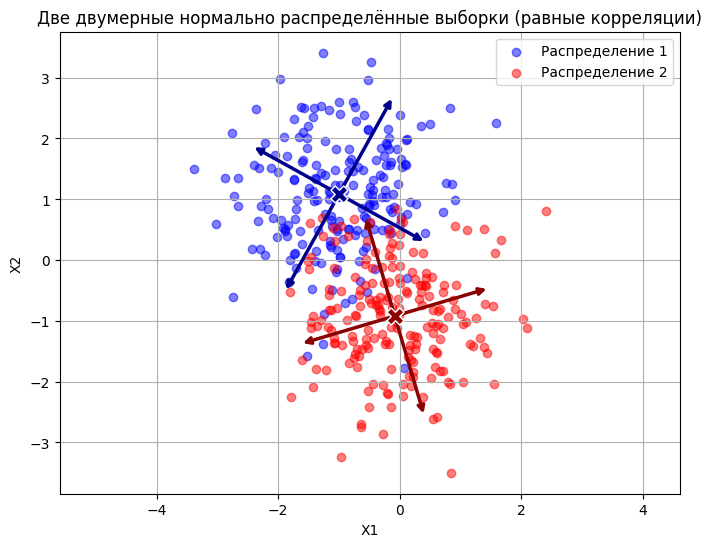

In [2]:
import matplotlib.pyplot as plt
import numpy as np

a = 0.7
b = 0
M1 = [-1, 1]
M2 = [0, -1]

B = [[a, b],
     [b, a]]

N = 200

print(mahalanobis_distance(M1, M2, B))

X1 = generate_normal_2d(M1, B, N)
X2 = generate_normal_2d(M2, B, N)

np.save('distrib_1_[-1,1].npy', X1)
np.save('distrib_2_[0,-1].npy', X2)

M_hat1 = X1.mean(axis=0)
B_hat1 = np.cov(X1, rowvar=False)  

print("Выборка 1:")
print("Оценка среднего:", M_hat1)
print("Оценка ковариации:\n", B_hat1)


M_hat2 = X2.mean(axis=0)
B_hat2 = np.cov(X2, rowvar=False)

print("\nВыборка 2:")
print("Оценка среднего:", M_hat2)
print("Оценка ковариации:\n", B_hat2)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(X1[:, 0], X1[:, 1], color='blue', alpha=0.5, label='Распределение 1')
ax.scatter(X2[:, 0], X2[:, 1], color='red', alpha=0.5, label='Распределение 2')

plot_distribution_features(M_hat1, B_hat1, ax, color='darkblue')
plot_distribution_features(M_hat2, B_hat2, ax, color='darkred')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Две двумерные нормально распределённые выборки (равные корреляции)')
ax.legend()
ax.grid(True)
plt.axis('equal') # Уравниваем оси, чтобы направления были геометрически точными
plt.show()

M1-M2
5.247473848334409
M1-M2
1.2474738483344092
M1-M3
8.627755538475254
7.142857142857143
Выборка 1:
Оценка среднего: [-1.1001737   0.99429048]
Оценка ковариации:
 [[ 0.79399849 -0.01019347]
 [-0.01019347  0.10212807]]

Выборка 2:
Оценка среднего: [ 0.06261919 -0.94703783]
Оценка ковариации:
 [[0.97791798 0.24866873]
 [0.24866873 0.42814926]]

Выборка 3:
Оценка среднего: [ 2.02639665 -1.04821545]
Оценка ковариации:
 [[ 1.01504508 -0.48416779]
 [-0.48416779  0.27996546]]


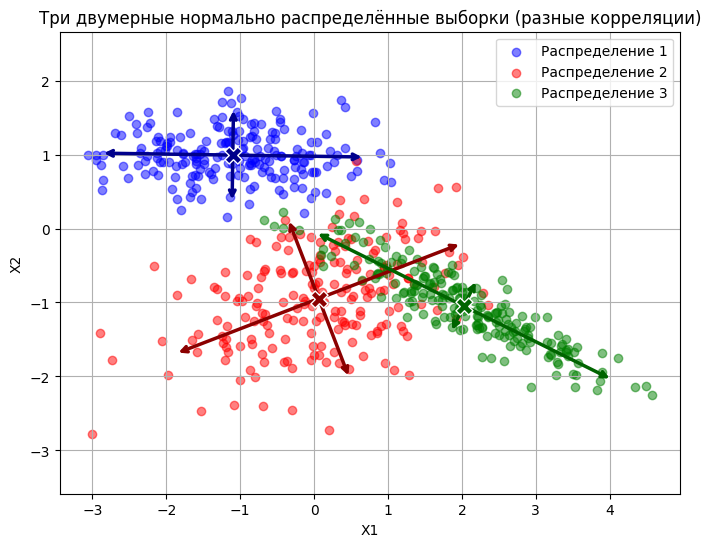

In [3]:
import matplotlib.pyplot as plt
import numpy as np

N = 200

M1 = [-1.0, 1.0]

B1 = [[0.9, 0],
     [0, 0.1]]

M2 = [0.0, -1.0]

B2 = [[1, 0.25],
     [0.25, 0.4]]


M3 = [2.0, -1.0]

B3 = [[1, -0.5],
     [-0.5, 0.3]]

print("M1-M2")
print(bhattacharyya_distance(M1, M2, B1, B2))
print("M1-M2")
print(bhattacharyya_distance(M2, M3, B1, B2))
print("M1-M3")
print(bhattacharyya_distance(M1, M3, B1, B2))

print(mahalanobis_distance(M1, M2, B))

X1 = generate_normal_2d(M1, B1, N)
X2 = generate_normal_2d(M2, B2, N)
X3 = generate_normal_2d(M3, B3, N)


M_hat1 = X1.mean(axis=0)
B_hat1 = np.cov(X1, rowvar=False)  

print("Выборка 1:")
print("Оценка среднего:", M_hat1)
print("Оценка ковариации:\n", B_hat1)


M_hat2 = X2.mean(axis=0)
B_hat2 = np.cov(X2, rowvar=False)

print("\nВыборка 2:")
print("Оценка среднего:", M_hat2)
print("Оценка ковариации:\n", B_hat2)

M_hat3 = X3.mean(axis=0)
B_hat3 = np.cov(X3, rowvar=False)

print("\nВыборка 3:")
print("Оценка среднего:", M_hat3)
print("Оценка ковариации:\n", B_hat3)


fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(X1[:, 0], X1[:, 1], color='blue', alpha=0.5, label='Распределение 1')
ax.scatter(X2[:, 0], X2[:, 1], color='red', alpha=0.5, label='Распределение 2')
ax.scatter(X3[:, 0], X3[:, 1], color='green', alpha=0.5, label='Распределение 3')

plot_distribution_features(M_hat1, B_hat1, ax, color='darkblue')
plot_distribution_features(M_hat2, B_hat2, ax, color='darkred')
plot_distribution_features(M_hat3, B_hat3, ax, color='darkgreen')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_title('Три двумерные нормально распределённые выборки (разные корреляции)')
ax.legend()
ax.grid(True)
plt.axis('equal')
plt.show()

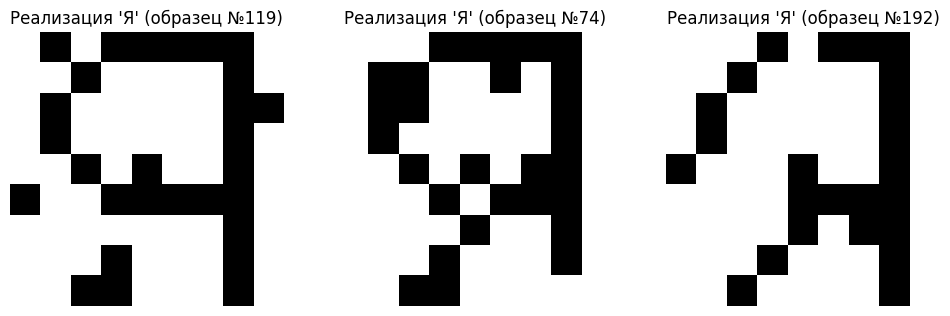

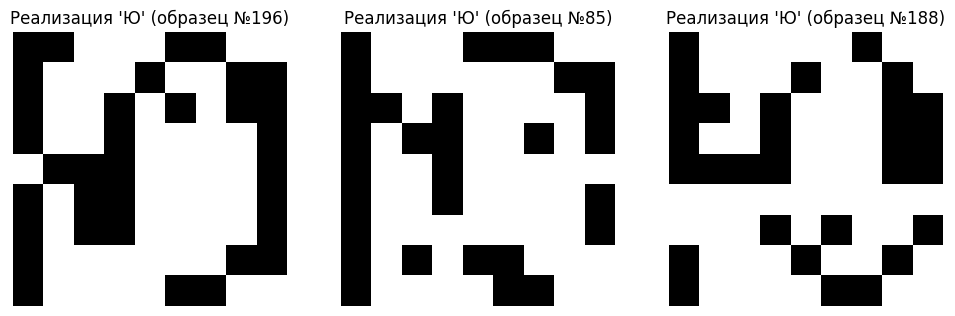

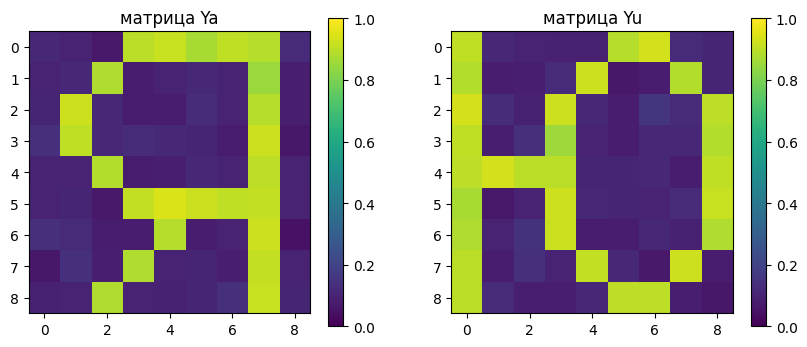

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def make_switch(base_matrix, N, p):
    """
    base_matrix — исходная 9x9 матрица
    N — количество реализаций
    p — вероятность изменения элемента
    """
    h, w = base_matrix.shape
    samples = np.zeros((N, h, w))

    for i in range(N):
        switch = np.random.rand(h, w) < p
        sample = base_matrix.copy()
        sample[switch] = 1 - sample[switch]
        samples[i] = sample

    return samples

def plot_samples(samples, title, count=3):
    plt.figure(figsize=(12, 4))
    for i in range(count):
        plt.subplot(1, count, i + 1)
        idx = np.random.randint(0, len(samples))
        plt.imshow(samples[idx], cmap='gray_r')
        plt.title(f"{title} (образец №{idx})")
        plt.axis('off')
    plt.show()

ya_array = np.array([
    [0, 0, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
])
yu_array = np.array([
    [1, 0, 0, 0, 0, 1, 1, 0, 0],
    [1, 0, 0, 0, 1, 0, 0, 1, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 0, 0, 0, 0, 1],
    [1, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 0, 0, 1, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 1, 1, 0, 0],
])


N = 200
p = 0.1

samples_ya = make_switch(ya_array, N, p)
samples_yu = make_switch(yu_array, N, p)

np.save('sample_ya.npy', samples_ya)
np.save('sample_yu.npy', samples_yu)

plot_samples(samples_ya, "Реализация 'Я'")
plot_samples(samples_yu, "Реализация 'Ю'")

mean_ya = samples_ya.mean(axis=0)
mean_yu = samples_yu.mean(axis=0)


plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(mean_ya, cmap='viridis', vmin=0, vmax=1)
plt.title("матрица Ya")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(mean_yu, cmap='viridis', vmin=0, vmax=1)
plt.title("матрица Yu")
plt.colorbar()

plt.show()